## essential libraries


In [2]:
import tensorflow as tf
from tensorflow. keras import models, layers 
import matplotlib.pyplot as plt
import numpy as np


In [3]:
IMAGE_SIZE = 256
BATCH_SİZE = 32
CHANELLS = 3
EPOCHS = 50 #as mouch as epochs our model will perform better but it will take more time to train the model

In [4]:
dataset =tf.keras.preprocessing.image_dataset_from_directory(
    "training" ,
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SİZE
)   

Found 2152 files belonging to 3 classes.


In [5]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [6]:
len(dataset) ## cuz we have 68 batches of data

68

In [7]:
68*32 ## 2176 images in total

2176

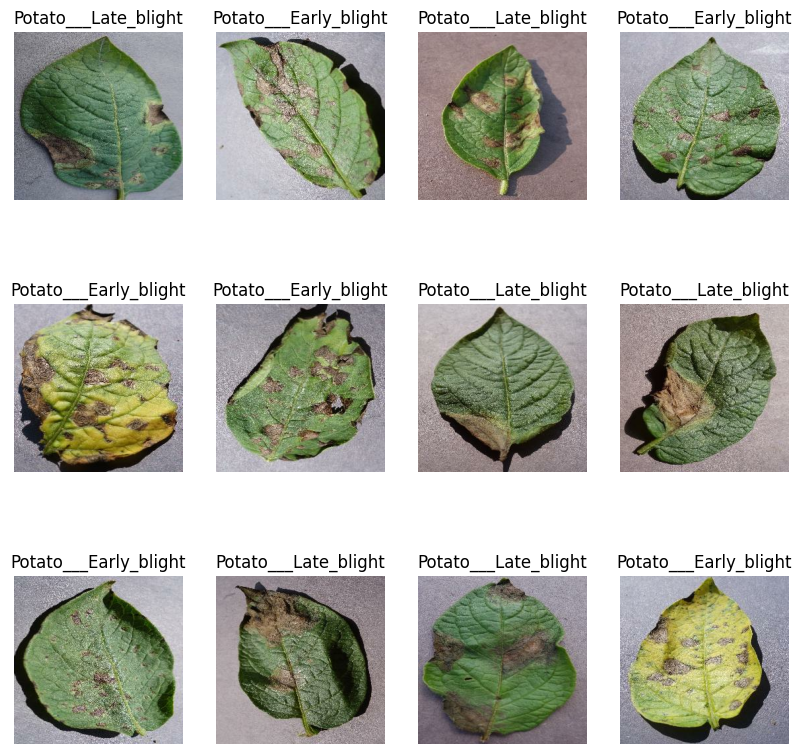

In [8]:
plt.figure(figsize=(10,10))

for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")



# we will use the following values 
80% training
 10% validation 
 10%test

In [9]:
len(dataset)
train_size = 0.8
len(dataset)*train_size 
train_ds = dataset.take(54)
len(train_ds)
remaining = dataset.skip(54)
len(remaining)
##this is the remaining 20% of the data for testing
val_size = 0.1
len(dataset)*val_size
val_ds = remaining.take(6)
len(val_ds)
test_ds = remaining.skip(6)
len(test_ds)

8

or we can just write a wel organized function for all above operations

In [10]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True,shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)


    return train_ds, val_ds, test_ds


In [11]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

we can boost the model by applying cache and prefetch methods (https://www.tensorflow.org/guide/data_performance)
-prefetch to optimize cpu and gpu proccessing time-cache to reduce the opening and reading the whole dataset each eopch

In [12]:
train_ds = train_ds.cache().shuffle (1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

if we feed our model with external deta we need to rescale it as below:

In [13]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),  # Resize images to (Image_Size, Image_Size)
    layers.Rescaling(1.0/255)  # Rescale pixel values from [0, 255] to [0, 1]
])

also we can apply a data augmentation layer to boost the model with extra data

In [14]:
data_augmentation = tf.keras.Sequential([
layers.RandomFlip("horizontal_and_vertical"), 
layers.RandomRotation (0.2),
])

## Building the model

In [15]:
input_shape = (BATCH_SİZE,IMAGE_SIZE, IMAGE_SIZE,CHANELLS)
n_classes = 3


model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3), activation="relu", input_shape= input_shape),# i gave 32 layers because it must be a power of 2 to optimize the gpu
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),#to convert the 2D feature maps into a 1D feature vector that can be fed into the fully connected layers
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax"),# to convert the output to a probability distribution over the classes


])
model.build(input_shape= input_shape)

/Users/ismail/mlProject/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(#this is for the training process
optimizer= 'adam',
loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
metrics=['accuracy' ]
)

In [18]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SİZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 619ms/step - accuracy: 0.4919 - loss: 0.9140 - val_accuracy: 0.4375 - val_loss: 0.8847
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 636ms/step - accuracy: 0.6036 - loss: 0.8246 - val_accuracy: 0.7708 - val_loss: 0.5793
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 674ms/step - accuracy: 0.7911 - loss: 0.4990 - val_accuracy: 0.8385 - val_loss: 0.3601
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 680ms/step - accuracy: 0.8449 - loss: 0.3561 - val_accuracy: 0.8906 - val_loss: 0.3241
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 45s 835ms/step - accuracy: 0.8802 - loss: 0.3084 - val_accuracy: 0.8906 - val_loss: 0.3044
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 751ms/step - accuracy: 0.8999 - loss: 0.2443 - val_accuracy: 0.9115 - val_loss: 0.2821
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 733ms/step - accuracy: 0.9097 - loss: 0.2340 - val_accuracy: 0.9010 - val_loss: 0.2309
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 743ms/step - accuracy: 0.9201 - loss: 0.2046 - val_accu

In [19]:
scores= model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - accuracy: 0.9883 - loss: 0.0472


In [20]:
history #(https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/History) for more details about the history object

In [21]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [22]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Performance Of The Model

In [23]:
acc = history. history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Accuracy')

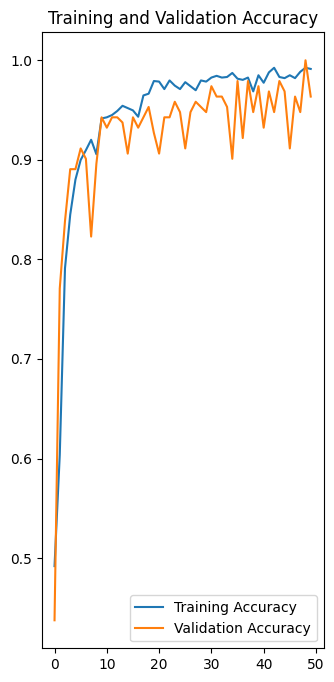

In [24]:

plt. figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt. plot(range(EPOCHS),val_acc, label='Validation Accuracy')
plt. legend(loc='lower right')
plt. title( 'Training and Validation Accuracy')

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step
              precision    recall  f1-score   support

           0       0.56      0.58      0.57        84
           1       0.60      0.55      0.57        94
           2       0.28      0.36      0.31        14

    accuracy                           0.55       192
   macro avg       0.48      0.50      0.49       192
weighted avg       0.56      0.55      0.55       192

Precision: 0.559287196679438
Recall: 0.5520833333333334


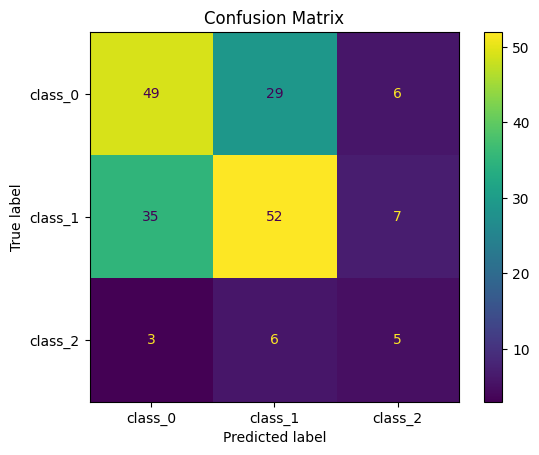

In [25]:
import numpy as np
from sklearn.metrics import classification_report, precision_score, recall_score,ConfusionMatrixDisplay, confusion_matrix

# Get predictions
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels from dataset
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# Full report
print(classification_report(y_true, y_pred))

# Individual scores
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['class_0', 'class_1', 'class_2']).plot()
plt.title('Confusion Matrix')
plt.show()

Testing the model 

first image to predict
actual label: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
predicted label:  Potato___Early_blight


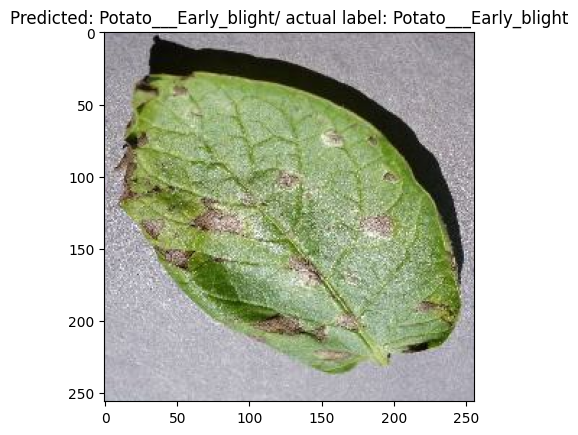

In [43]:
for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    print("first image to predict")
    plt. imshow(first_image)
    print("actual label:",class_names[first_label])
    batch_prediction = model. predict(images_batch)
    print("predicted label: ",class_names[np.argmax(batch_prediction[0])])
    plt.title("Predicted: " + class_names[np.argmax(batch_prediction[0])]+ "/"+" actual label: " + class_names[first_label])
    



# wrong samples

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


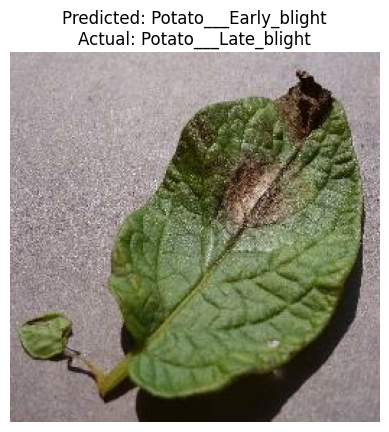

In [50]:
wrong_images = []
wrong_predictions = []
wrong_actual = []

for images_batch, labels_batch in test_ds:
    batch_predictions = model.predict(images_batch)
    
    for i in range(len(labels_batch)):
        actual = labels_batch[i].numpy()
        predicted = np.argmax(batch_predictions[i])
        
        if actual != predicted:
            wrong_images.append(images_batch[i].numpy().astype('uint8'))
            wrong_predictions.append(predicted)
            wrong_actual.append(actual)

# Sadece ilk yanlışı göster
if wrong_images:
    plt.imshow(wrong_images[0])
    plt.title(
        f"Predicted: {class_names[wrong_predictions[0]]}\n"
        f"Actual: {class_names[wrong_actual[0]]}"
    )
    plt.axis("off")
    plt.show()
else:
    print("Hiç yanlış tahmin yok!")

the model usualy crashes at late blight class